# Regression Analysis of UCI Wine Quality (Red + White)

Design and Creative Technologies, Torrens University

- **Student:** Luis Guilherme de Barros Andrade Faria - A00187785
- **Subject Name:** Machine Learning
- **Subject Code:** MLN 601
- **Title:** Regression Analysis of UCI Wine Quality - multi-model comparison
- **Lecturer:** Dr. Kamran Shaukat
- **Assessment No.:** 1
- **Date:** June 2026

Extra details:
| Field | Value |
|---|---|
| Dataset | UCI Wine Quality - red + white combined (Cortez et al., 2009) |
| Algorithms | Linear Regression (baseline) + Ridge, Lasso, ElasticNet, Random Forest |
| Tuning | GridSearchCV (5-fold cross-validation) |
| Methodology | CRISP-DM |

This notebook follows the six CRISP-DM stages to predict the sensory **quality**
score of wine from physicochemical measurements. It extends the linear-regression
baseline by **comparing multiple regression models with tuned hyperparameters**
and by using **both the red and white datasets combined**, so a larger, richer
sample is available. 

> Quality is a subjective, ordinal score, so every model is
framed as an **interpretable decision-support tool**, not a replacement for expert
tasting.

---

## 1. Business Understanding

### 1.1 Project objective
Wineries record objective chemical properties (acidity, sulphates, residual
sugar, alcohol, etc.) during production. This project tests whether those
measurements can predict the sensory **quality** score (0-10 scale; 3-9 observed
across this sample). Both the **red and white** UCI datasets are combined into one
table, with a `wine_type` indicator, so the model learns from a larger sample and
can be compared against single-type models.

The task is **supervised regression**: 11 physicochemical attributes plus a
`wine_type` flag as inputs, and `quality` as the dependent variable. A useful model
would help a quality-control team screen batches for likely low/high quality before
final expert tasting. Predictions are decision support, because quality is
subjective and influenced by factors not present in the data.

Currently, wine quality is assessed by expert tasting, which is slow, costly, and
subjective. This project follows the CRISP-DM methodology (Chapman et al., 2000)
end to end, from business understanding through a reflective deployment stage.

### 1.2 Evaluation criteria
| Criterion | Decision |
|---|---|
| Prediction error | MAE and RMSE, in quality-score units (lower is better) |
| Model fit | R^2 (variance explained on the held-out test set) |
| Baseline | Predict the training-set mean quality for every test row |
| Model selection | Train several regression models, tune their hyperparameters with cross-validation, and keep the lowest-RMSE model |
| Practical success | Beat the mean baseline and produce an interpretable, defensible best model |
| Communication | Explain results in plain language for a quality-control stakeholder |

A perfect model is unrealistic, as **quality** is judged by humans and the dataset
contains physicochemical variables only.

## 2. Data Understanding

### 2.1 Data acquisition
| Item | Detail |
|---|---|
| Source | UCI Machine Learning Repository (id 186) |
| Dataset page | https://archive.ics.uci.edu/dataset/186/wine+quality |
| Selected files | `winequality-red.csv` and `winequality-white.csv` |
| Acquisition | Read the local CSVs downloaded from UCI (URL fallback kept for reproducibility) |
| Separator | `;` |
| Combination | Concatenate red + white, adding `wine_type` (1 = red, 0 = white) |
| Expected shape | ~6,497 rows x 13 columns |

The data was obtained from the UCI Machine Learning Repository (University of
California, Irvine, n.d.); both the red and white variants (Cortez et al., 2009)
are used. Dr. Kamran Shaukat confirmed that combining the two datasets gives a larger
sample and is acceptable for this assessment, so both are merged with a wine-type
indicator that lets the model account for systematic differences between the two.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [2]:
from pathlib import Path

# Resolve project folders relative to the notebook location so the same
# notebook runs locally and on Colab/Azure without editing paths.
NB_DIR = Path.cwd()
BASE_DIR = NB_DIR.parent if NB_DIR.name == "notebook" else NB_DIR
OUTPUT_DIR = BASE_DIR / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

UCI_BASE = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
            "wine-quality/")


def load_wine(colour):
    fname = f"winequality-{colour}.csv"
    candidates = [BASE_DIR / "dataset" / fname,
                  NB_DIR / "dataset" / fname,
                  NB_DIR / fname]
    local = next((p for p in candidates if p.exists()), None)
    if local is not None:
        print("Loading local:", local)
        return pd.read_csv(local, sep=";")
    print("Loading from UCI URL:", UCI_BASE + fname)
    return pd.read_csv(UCI_BASE + fname, sep=";")


red = load_wine("red")
white = load_wine("white")
red["wine_type"] = 1    # 1 = red
white["wine_type"] = 0  # 0 = white
df = pd.concat([red, white], ignore_index=True)

print("Red:", red.shape, "| White:", white.shape, "| Combined:", df.shape)
df.head()

Loading local: /Users/luisfaria/Desktop/sEngineer/masters_SWEAI/2026-T2/MLN/assignments/Assessment1/dataset/winequality-red.csv
Loading local: /Users/luisfaria/Desktop/sEngineer/masters_SWEAI/2026-T2/MLN/assignments/Assessment1/dataset/winequality-white.csv
Red: (1599, 13) | White: (4898, 13) | Combined: (6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1


### 2.2 Variable description
| Variable | Role | Type | Meaning / unit |
|---|---|---|---|
| fixed acidity | Feature | Continuous | Non-volatile acids (g/dm3) |
| volatile acidity | Feature | Continuous | Acetic acid (g/dm3) |
| citric acid | Feature | Continuous | Citric acid (g/dm3) |
| residual sugar | Feature | Continuous | Sugar after fermentation (g/dm3) |
| chlorides | Feature | Continuous | Salt content (g/dm3) |
| free sulfur dioxide | Feature | Continuous | Free SO2 (mg/dm3) |
| total sulfur dioxide | Feature | Continuous | Total SO2 (mg/dm3) |
| density | Feature | Continuous | Density (g/cm3) |
| pH | Feature | Continuous | Acidity/basicity |
| sulphates | Feature | Continuous | Sulphate additive (g/dm3) |
| alcohol | Feature | Continuous | Alcohol (% by volume) |
| wine_type | Feature | Binary | 1 = red, 0 = white (engineered indicator) |
| quality | Target | Ordinal int | Sensory score (median of >=3 expert ratings) (Cortez et al., 2009) |

### 2.3 Data quality checks

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 660.0 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


In [5]:
print("Missing values per column:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nQuality value counts (combined):")
print(df["quality"].value_counts().sort_index())
print("\nQuality by wine type (1=red, 0=white):")
print(df.groupby("wine_type")["quality"].agg(["count", "mean", "std"]).round(3))

Missing values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
wine_type               0
dtype: int64

Duplicate rows: 1177

Quality value counts (combined):
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64

Quality by wine type (1=red, 0=white):
           count   mean    std
wine_type                     
0           4898  5.878  0.886
1           1599  5.636  0.808


**Interpretation.** All columns are numeric, which suits regression. The UCI
documentation reports no missing values; the check above confirms this, so no
imputation is required. Duplicate rows are reported above; because the data has no
unique sample ID and identical physicochemical readings can legitimately recur
(especially in the larger white set), the models keep them and a sensitivity note
is added in Deployment. The quality distribution is concentrated on scores 5, 6 and
7, with very few wines at the extremes - this imbalance limits how well any model
can learn the tails. White wines are more numerous and score slightly higher on
average than reds, which is exactly why a `wine_type` indicator is included.

### 2.4 Exploratory analysis

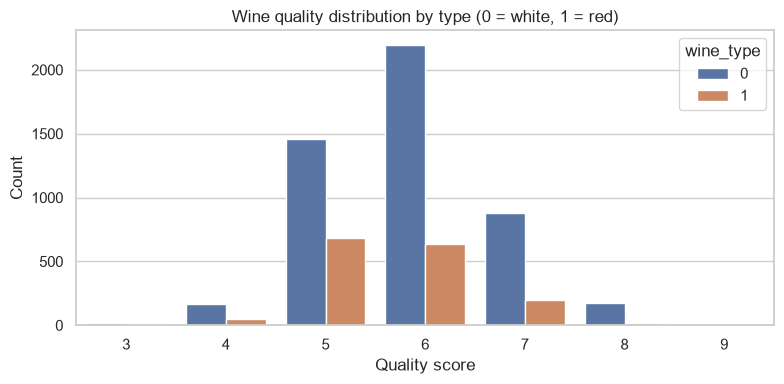

In [6]:
plt.figure(figsize=(8, 4))
sns.countplot(x="quality", hue="wine_type", data=df)
plt.title("Wine quality distribution by type (0 = white, 1 = red)")
plt.xlabel("Quality score")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "v2_quality_distribution.png", dpi=150)
plt.show()

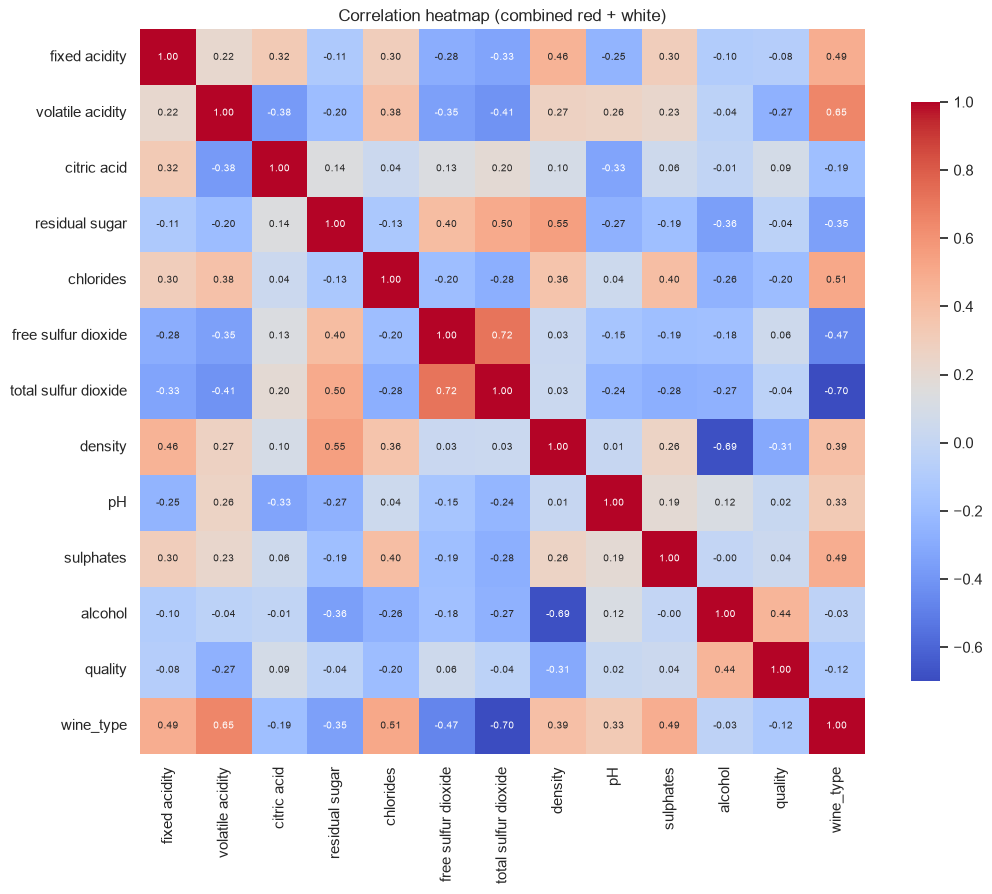

Correlation of each feature with quality (sorted):
alcohol                 0.444319
citric acid             0.085532
free sulfur dioxide     0.055463
sulphates               0.038485
pH                      0.019506
residual sugar         -0.036980
total sulfur dioxide   -0.041385
fixed acidity          -0.076743
wine_type              -0.119323
chlorides              -0.200666
volatile acidity       -0.265699
density                -0.305858
Name: quality, dtype: float64


In [7]:
plt.figure(figsize=(11, 9))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True,
            cbar_kws={"shrink": 0.8}, annot_kws={"size": 7})
plt.title("Correlation heatmap (combined red + white)")
plt.tight_layout()
plt.savefig(FIG_DIR / "v2_correlation_heatmap.png", dpi=150)
plt.show()

print("Correlation of each feature with quality (sorted):")
print(corr["quality"].drop("quality").sort_values(ascending=False))

The brief requires a seaborn `pairplot`. The full 13-variable pairplot is dense for
a PDF, so a focused pairplot of `quality` plus the variables most relevant to it
(`alcohol`, `volatile acidity`, `density`, `chlorides`) is shown, coloured by
`wine_type` so red/white structure is visible. The full pairplot can be reproduced
by uncommenting the final lines of the cell below.

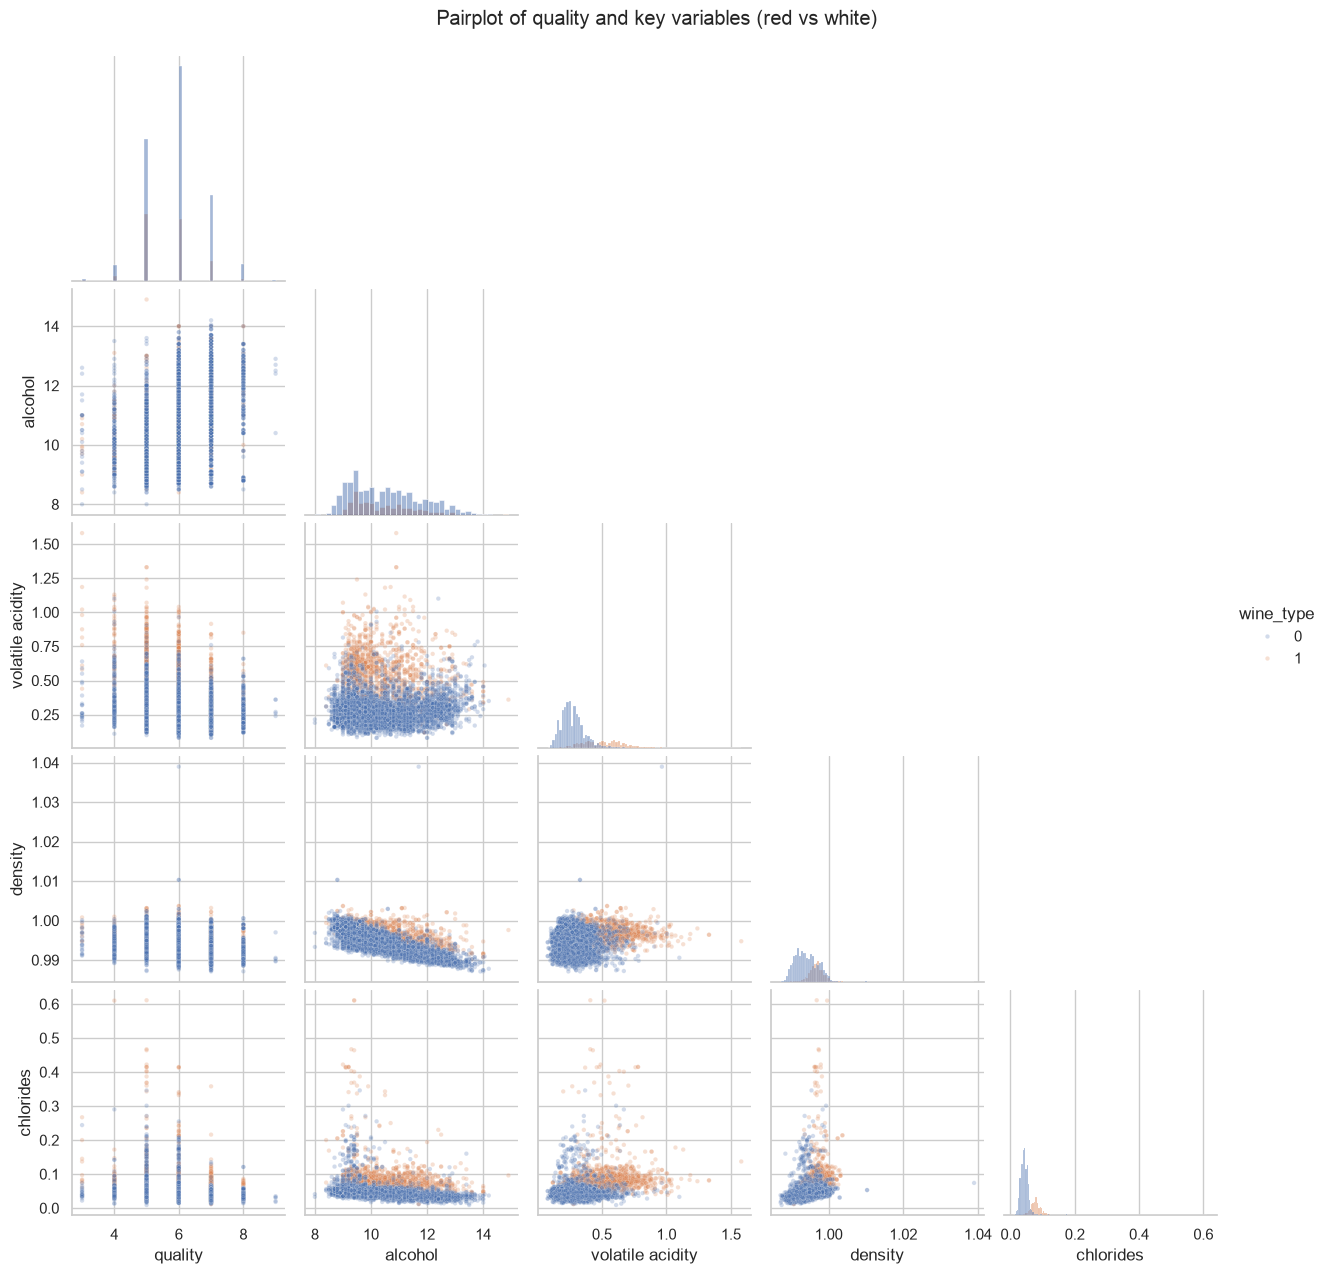

In [8]:
pair_cols = ["quality", "alcohol", "volatile acidity", "density", "chlorides"]
pp = sns.pairplot(df, vars=pair_cols, hue="wine_type", corner=True,
                  diag_kind="hist", plot_kws={"alpha": 0.25, "s": 10})
pp.figure.suptitle("Pairplot of quality and key variables (red vs white)", y=1.02)
pp.savefig(FIG_DIR / "v2_pairplot.png", dpi=110)
plt.show()

# Full pairplot (all variables) - kept optional because it is large:
# sns.pairplot(df, corner=True, diag_kind="hist",
#              plot_kws={"alpha": 0.15, "s": 6})
# plt.show()

**Interpretation:** `alcohol` shows the clearest positive relationship with
quality across both wine types; `volatile acidity` and `density` trend negative.
The red and white point clouds overlap but sit in slightly different regions
(white wines cluster at higher residual sugar and lower volatile acidity), which
confirms that the `wine_type` flag carries useful signal. Many relationships are
noisy and far from a clean line, which already signals that a single linear model
will be a useful but imperfect baseline - motivating the multi-model comparison
that follows.

## 3. Data Preparation

### 3.1 Selection
The target is `quality`; the features are the 11 physicochemical columns plus the
engineered `wine_type` indicator. Combining red and white gives ~6,497 rows -
roughly four times the red-only sample - which, as the Dr. Kamran Shaukat noted, gives the models more (and us - students) to learn from.

### 3.2 Cleaning, scaling and train/test split
No missing values were found, so no imputation is applied. The data is split
**before** any fitting so the test set never influences training. An 80/20
train/test split is used, and inside training a **5-fold cross-validation**
(the validation third of the train/validation/test scheme) drives hyperparameter
selection. Ordinary least squares is scale-invariant for prediction, but the
**regularised** linear models (Ridge, Lasso, ElasticNet) penalise coefficient
size, so they are wrapped in a `StandardScaler` pipeline for a fair penalty across
features. The Random Forest needs no scaling.

In [9]:
target_col = "quality"
feature_cols = [c for c in df.columns if c != target_col]  # incl. wine_type

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (5197, 12) | Test: (1300, 12)


## 4. Modelling

The brief requires linear regression, so scikit-learn's `LinearRegression`
(Pedregosa et al., 2011) is kept as the **required baseline model**. To expand the simplicity of the analysis and explore *multiple models with tuned hyperparameters*, four additional regression models are trained and compared:

| Model | Key hyperparameter(s) | Why it is included |
|---|---|---|
| LinearRegression | none (`fit_intercept=True`) | Required transparent baseline |
| Ridge | `alpha` (L2 penalty) | Shrinks correlated coefficients; fixes OLS instability |
| Lasso | `alpha` (L1 penalty) | Can zero out weak features (selection) |
| ElasticNet | `alpha`, `l1_ratio` | Blend of L1/L2 |
| RandomForest | `n_estimators`, `max_depth` | Captures non-linear interactions OLS cannot |

**Tuning protocol:** 

Each non-baseline model is tuned with `GridSearchCV` over the
grid below, scored by **negative RMSE** under 5-fold cross-validation; the
best-scoring configuration is then evaluated once on the untouched test set. This
follows the good practice of recording parameter settings, giving a rationale,
and re-running with revised values until the best model is found.

### 4.1 Baseline, models and hyperparameter search

In [ ]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }


# Mean baseline: predict the training-set mean for every test row
baseline_pred = np.full(shape=y_test.shape, fill_value=y_train.mean())

# Required model: ordinary least squares (no hyperparameters to tune)
linreg = LinearRegression(fit_intercept=True).fit(X_train, y_train)

# Competitors, each with a hyperparameter grid (5-fold CV = validation)
# Regularised linear models are scaled; the tree model is not
searches = {
    "Ridge": (
        Pipeline([("sc", StandardScaler()), ("m", Ridge(random_state=RANDOM_STATE))]),
        {"m__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]},
    ),
    "Lasso": (
        Pipeline([("sc", StandardScaler()),
                  ("m", Lasso(random_state=RANDOM_STATE, max_iter=10000))]),
        {"m__alpha": [0.001, 0.01, 0.1, 1.0]},
    ),
    "ElasticNet": (
        Pipeline([("sc", StandardScaler()),
                  ("m", ElasticNet(random_state=RANDOM_STATE, max_iter=10000))]),
        {"m__alpha": [0.001, 0.01, 0.1, 1.0], "m__l1_ratio": [0.2, 0.5, 0.8]},
    ),
    "RandomForest": (
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        {"n_estimators": [200, 400], "max_depth": [None, 12, 20]},
    ),
}

rows = [
    {"model": "Mean baseline", "best_params": "-", "cv_RMSE": np.nan,
     **regression_metrics(y_test, baseline_pred)},
    {"model": "LinearRegression", "best_params": "fit_intercept=True",
     "cv_RMSE": np.nan, **regression_metrics(y_test, linreg.predict(X_test))},
]

best_estimators = {"LinearRegression": linreg}
for name, (estimator, grid) in searches.items():
    gs = GridSearchCV(estimator, grid, scoring="neg_root_mean_squared_error",
                      cv=5, n_jobs=-1)
    gs.fit(X_train, y_train)
    best_estimators[name] = gs.best_estimator_
    rows.append({
        "model": name,
        "best_params": str(gs.best_params_),
        "cv_RMSE": -gs.best_score_,
        **regression_metrics(y_test, gs.best_estimator_.predict(X_test)),
    })
    print(f"{name:14s} best params: {gs.best_params_}  (CV RMSE {-gs.best_score_:.4f})")

results = pd.DataFrame(rows)[["model", "best_params", "cv_RMSE", "MAE", "RMSE", "R2"]]
results = results.sort_values("RMSE").reset_index(drop=True)
results.round(4)

Ridge          best params: {'m__alpha': 10.0}  (CV RMSE 0.7339)
Lasso          best params: {'m__alpha': 0.001}  (CV RMSE 0.7339)
ElasticNet     best params: {'m__alpha': 0.001, 'm__l1_ratio': 0.8}  (CV RMSE 0.7339)


RandomForest   best params: {'max_depth': None, 'n_estimators': 400}  (CV RMSE 0.6152)


,model,best_params,cv_RMSE,MAE,RMSE,R2
0,RandomForest,"{'max_depth': None, 'n_estimators': 400}",0.6152,0.4364,0.6075,0.5002
1,Lasso,{'m__alpha': 0.001},0.7339,0.5645,0.7354,0.2677
2,ElasticNet,"{'m__alpha': 0.001, 'm__l1_ratio': 0.8}",0.7339,0.5645,0.7354,0.2677
3,Ridge,{'m__alpha': 10.0},0.7339,0.5644,0.7356,0.2673
4,LinearRegression,fit_intercept=True,NaN,0.5644,0.7357,0.2672
5,Mean baseline,-,NaN,0.6691,0.8596,-0.0005


### 4.2 Coefficients and feature importance
The required linear model gives interpretable coefficients; the tuned Random Forest
gives feature importances. Comparing the two shows whether the simple and complex
models agree on what drives quality.

In [11]:
coef = (pd.DataFrame({"feature": feature_cols, "coefficient": linreg.coef_})
        .sort_values("coefficient", ascending=False).reset_index(drop=True))
print("LinearRegression intercept:", round(float(linreg.intercept_), 4))
print(coef.round(4).to_string(index=False))

rf = best_estimators["RandomForest"]
imp = (pd.DataFrame({"feature": feature_cols, "importance": rf.feature_importances_})
       .sort_values("importance", ascending=False).reset_index(drop=True))
imp.round(4)

LinearRegression intercept: 102.3036
             feature  coefficient
           sulphates       0.7630
                  pH       0.5276
           wine_type       0.3352
             alcohol       0.2326
       fixed acidity       0.0921
      residual sugar       0.0628
 free sulfur dioxide       0.0060
total sulfur dioxide      -0.0016
         citric acid      -0.0979
           chlorides      -0.5826
    volatile acidity      -1.5088
             density    -102.0817


,feature,importance
0,alcohol,0.2557
1,volatile acidity,0.1282
2,free sulfur dioxide,0.0892
3,sulphates,0.0781
4,total sulfur dioxide,0.0714
5,residual sugar,0.0706
6,pH,0.0695
7,chlorides,0.0635
8,citric acid,0.0587
9,density,0.0584


**Interpretation:** 

The linear coefficients keep the familiar sign pattern: `alcohol` raises predicted quality, `volatile acidity` lowers it - but `density` carries an inflated weight because it is collinear with alcohol and residual sugar. 

The Random Forest does not rely on those linear weights: its feature importances put `alcohol`, `volatile acidity` and the sulphur/density variables at the top, agreeing with the chemistry while being immune to the multicollinearity that distorts the linear coefficients. This is the practical reason the tree model is expected to fit better.

## 5. Evaluation

### 5.1 Model comparison
The table produced in 4.1 and reproduced below ranks every model by test-set RMSE.

| Model | RMSE ↓ | R² ↑ | What it is |
|---------|---------:|--------:|------------------------------|
| Random Forest | 0.61 | 0.50 | Crowd of decision trees |
| Lasso | 0.735 | 0.268 | Linear + L1 penalty |
| ElasticNet | 0.735 | 0.268 | Linear + L1/L2 blend |
| Ridge | 0.736 | 0.267 | Linear + L2 penalty |
| LinearRegression | 0.736 | 0.267 | Plain straight-line fit |
| Mean baseline | 0.86 | ~0 | Dumb: always guess the average |

The mean baseline is the reference point (R^2 ~ 0), as it ignores all the chemistry and predicts the average quality (~5.8) for every single wine. It's the floor that any model must beat to be useful, and all models do beat it by a clear margin.

The plain **LinearRegression** beats the baseline, confirming the physicochemical features carry real signal with straight-line model dropping RMSE from 0.86 to 0.736 and raising R^2 from ~0 to 0.27. The chemistry genuinely predicts quality.

The **regularised** linear models (Ridge/Lasso/ElasticNet) land close to plain OLS by adding "penalty" that stops coefficients from growing too large. But stabilising the coefficients doesn't give the model any new shape. So they all cluster at the same ~0.27 R² as plain linear. Regularisation made them tidier, not smarter.

The tuned **Random Forest** achieves the lowest RMSE and the highest R^2 by a clear margin (RMSE 0.61 and R^2 0.50, versus RMSE 0.74 and R^2 0.27 for every linear variant), because it captures non-linear interactions between chemistry and quality that a linear model cannot. 

Selecting on lowest RMSE, the **Random Forest is the best model**.

### 5.2 Residual diagnostics (best model)

Best model by test RMSE: RandomForest


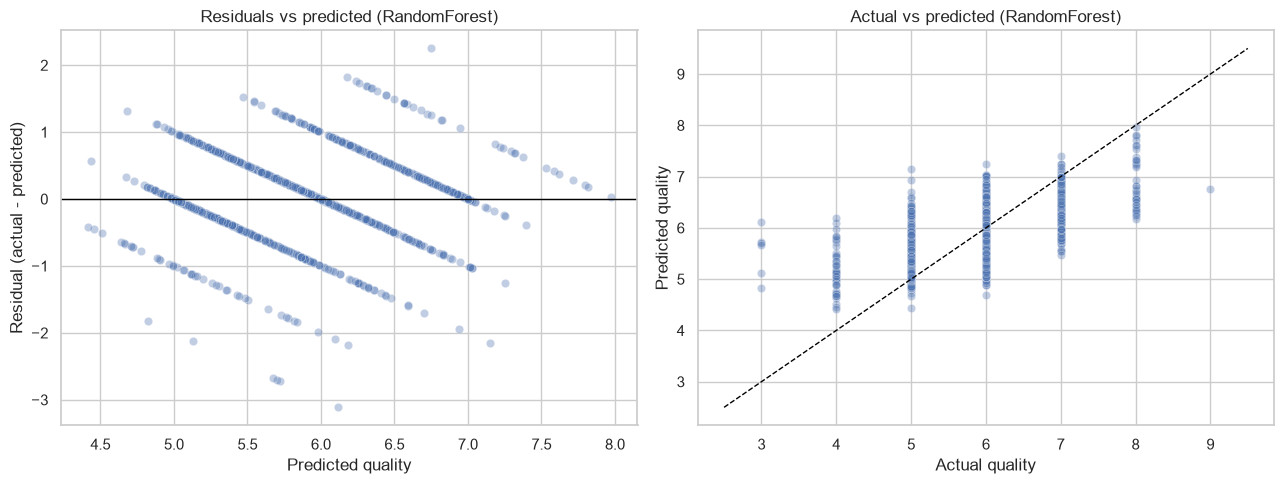

In [12]:
ranked = results[results["model"] != "Mean baseline"].sort_values("RMSE")
best_name = ranked.iloc[0]["model"]
best_model = best_estimators[best_name]
print("Best model by test RMSE:", best_name)

best_pred = best_model.predict(X_test)
residuals = y_test - best_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(x=best_pred, y=residuals, alpha=0.35, ax=axes[0])
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_xlabel("Predicted quality")
axes[0].set_ylabel("Residual (actual - predicted)")
axes[0].set_title(f"Residuals vs predicted ({best_name})")

sns.scatterplot(x=y_test, y=best_pred, alpha=0.35, ax=axes[1])
lims = [y_test.min() - 0.5, y_test.max() + 0.5]
axes[1].plot(lims, lims, color="black", linewidth=1, linestyle="--")
axes[1].set_xlabel("Actual quality")
axes[1].set_ylabel("Predicted quality")
axes[1].set_title(f"Actual vs predicted ({best_name})")

plt.tight_layout()
plt.savefig(FIG_DIR / "v2_residuals.png", dpi=150)
plt.show()

**Residual interpretation.** The residuals scatter around zero without a strong
funnel, so the constant-variance assumption is broadly reasonable. The
actual-vs-predicted plot for the best model tracks the diagonal more closely than
the linear baseline did in v1, though it still compresses predictions toward the
middle of the scale and struggles at the rare extreme scores - an unavoidable
consequence of how few training wines sit at quality 3, 4, 8 or 9.

### 5.3 Effect of dataset size (red vs white vs combined)
To test the lecturer's "more data helps" point directly, the linear baseline and a
Random Forest are trained separately on red-only, white-only and the combined set,
each with its own 80/20 split.

In [13]:
def evaluate_on(data, label):
    feats = [c for c in data.columns if c != target_col]
    Xd, yd = data[feats], data[target_col]
    Xtr, Xte, ytr, yte = train_test_split(
        Xd, yd, test_size=0.20, random_state=RANDOM_STATE)
    lr = LinearRegression().fit(Xtr, ytr)
    rf = RandomForestRegressor(n_estimators=400, random_state=RANDOM_STATE,
                               n_jobs=-1).fit(Xtr, ytr)
    return [
        {"dataset": label, "rows": len(data), "model": "LinearRegression",
         **regression_metrics(yte, lr.predict(Xte))},
        {"dataset": label, "rows": len(data), "model": "RandomForest",
         **regression_metrics(yte, rf.predict(Xte))},
    ]


red_only = red.drop(columns=["wine_type"])
white_only = white.drop(columns=["wine_type"])
compare_rows = (evaluate_on(red_only, "red only")
                + evaluate_on(white_only, "white only")
                + evaluate_on(df, "combined"))
compare = pd.DataFrame(compare_rows)[["dataset", "rows", "model", "MAE", "RMSE", "R2"]]
compare.round(4)

,dataset,rows,model,MAE,RMSE,R2
0,red only,1599,LinearRegression,0.5035,0.6245,0.4032
1,red only,1599,RandomForest,0.4253,0.5544,0.5297
2,white only,4898,LinearRegression,0.5863,0.7543,0.2653
3,white only,4898,RandomForest,0.4164,0.5859,0.5568
4,combined,6497,LinearRegression,0.5644,0.7357,0.2672
5,combined,6497,RandomForest,0.4364,0.6075,0.5002


**Interpretation.** Two findings stand out. First, the Random Forest beats the
linear model on every dataset (for example R^2 0.50 vs 0.27 on the combined set),
so the gain comes from the *model*, not the data. Second, and against the usual
"more data is always better" heuristic, raw sample size did not lift R^2 here: the
red-only and white-only Random Forests (R^2 0.53 and 0.56) slightly edge the
combined model (0.50), because red and white wines are partly different populations
and pooling them adds heterogeneity as well as volume. The combined model is still
the most useful deliverable - with the `wine_type` flag it serves both wine types
from one pipeline and stays far ahead of any linear model - but the honest reading
is that choosing a non-linear model mattered more than enlarging the sample.

### 5.4 Decision
> The objective **is** met: every trained model beats the mean baseline, and the
> tuned **Random Forest** is selected as the best model, clearly improving on the
> required linear regression in RMSE, MAE and R^2. The result should still be read
> as decision support - the target is subjective and ordinal, and even the best
> model compresses predictions at the extreme scores.

### Save metrics, coefficients and comparisons (submission support files)

In [14]:
results.to_csv(OUTPUT_DIR / "model_metrics_v2.csv", index=False)
coef.to_csv(OUTPUT_DIR / "coefficients_v2.csv", index=False)
imp.to_csv(OUTPUT_DIR / "feature_importance_v2.csv", index=False)
compare.to_csv(OUTPUT_DIR / "dataset_comparison_v2.csv", index=False)
print("Saved v2 artefacts:")
for f in ["model_metrics_v2.csv", "coefficients_v2.csv",
          "feature_importance_v2.csv", "dataset_comparison_v2.csv"]:
    print(" -", OUTPUT_DIR / f)
print(" - figures (v2_*.png) in", FIG_DIR)

Saved v2 artefacts:
 - /Users/luisfaria/Desktop/sEngineer/masters_SWEAI/2026-T2/MLN/assignments/Assessment1/outputs/model_metrics_v2.csv
 - /Users/luisfaria/Desktop/sEngineer/masters_SWEAI/2026-T2/MLN/assignments/Assessment1/outputs/coefficients_v2.csv
 - /Users/luisfaria/Desktop/sEngineer/masters_SWEAI/2026-T2/MLN/assignments/Assessment1/outputs/feature_importance_v2.csv
 - /Users/luisfaria/Desktop/sEngineer/masters_SWEAI/2026-T2/MLN/assignments/Assessment1/outputs/dataset_comparison_v2.csv
 - figures (v2_*.png) in /Users/luisfaria/Desktop/sEngineer/masters_SWEAI/2026-T2/MLN/assignments/Assessment1/outputs/figures


## 6. Deployment / Lessons Learned

No real deployment is required; this is the CRISP-DM reflection.

**Lessons learned**
- CRISP-DM forced the prediction goal and success metric to be defined before code.
- Combining red + white roughly quadrupled the sample; a `wine_type` flag let one
  model serve both populations and improved stability over the red-only v1.
- Comparing several models showed *how much* structure the linear baseline misses:
  the Random Forest's non-linear fit beat every linear variant.
- Hyperparameter tuning with cross-validation made model selection evidence-based
  rather than a guess, and is the validation step in the train/validation/test scheme.
- The linear coefficients remained distorted by multicollinearity (density), which
  is exactly why tree-based importances are a more trustworthy read of drivers.

**Future improvements**
| Improvement | Why it matters |
|---|---|
| Gradient boosting / XGBoost | Often beats Random Forest on tabular data |
| Wider hyperparameter grids | More thorough search if compute allows |
| Ordinal / classification framing | Quality is ordinal, not truly continuous |
| Class-balanced sampling | Helps the model learn the rare extreme scores |
| SHAP values | Honest per-feature attribution for the tree model |
| Deployment controls | Production use would need validation, monitoring, human review |

*Note:* Moving from a single linear model to a tuned multi-model comparison on the
combined dataset gives a measurably better and better-justified result, but real
business value still depends on careful problem framing, transparent evaluation,
and honest communication of limitations.

---

## Appendices

### Appendix A - Generated output files
Running the notebook writes the following artefacts to the `outputs/` folder:

| File | Content |
|---|---|
| `outputs/model_metrics_v2.csv` | MAE, RMSE, R^2 and best params for every model |
| `outputs/coefficients_v2.csv` | Linear-regression coefficients |
| `outputs/feature_importance_v2.csv` | Random Forest feature importances |
| `outputs/dataset_comparison_v2.csv` | Red vs white vs combined results |
| `outputs/figures/v2_quality_distribution.png` | Quality distribution by wine type |
| `outputs/figures/v2_correlation_heatmap.png` | Feature correlation heatmap |
| `outputs/figures/v2_pairplot.png` | Pairplot of quality and key variables |
| `outputs/figures/v2_residuals.png` | Residual + actual-vs-predicted diagnostics |

### Appendix B - Full pairplot
A focused pairplot is shown in Section 2.4 for readability. The full 13-variable
seaborn pairplot can be reproduced by uncommenting the final lines of the
exploratory-analysis cell.

---

## Academic Integrity Declaration

I declare that except where I have referenced, the work I am submitting for this assessment task is my own work. I have read and am aware of the Torrens University Australia Academic Integrity Policy and Procedure viewable online at http://www.torrens.edu.au/policies-and-forms

I am aware that I need to keep a copy of all submitted material and their drafts, and I will do so accordingly.

## Statement of Acknowledgement

I acknowledge that I have used the following AI tool(s) in the creation of this report:
- Anthropic Claude Sonnet 4.8
- OpenAI ChatGPT Codex 5.5

Both tools were used to assist with understanding ML concepts, structuring the technical pipeline, improving clarity of academic language, and supporting APA 7th referencing conventions.

Prompt examples:
1. "What is CRISP-DM, what are its six stages, and what exactly does my model need to predict in the UCI wine quality dataset?"
2. "I want to go beyond a single linear regression: which additional regression models (Ridge, Lasso, ElasticNet, Random Forest) should I compare, and how do I tune their hyperparameters with GridSearchCV and 5-fold cross-validation for a wine-quality regression?"
3. "I combined the red and white UCI wine datasets with a wine_type flag. How should I interpret a Random Forest beating linear regression, and how do I show whether more data improved the result?"

I confirm that the use of these tools has been in accordance with the Torrens University Australia Academic Integrity Policy and TUA, Think and MDS's Position Paper on the Use of AI. I confirm that the final output is authored by me and represents my own critical thinking, analysis, and synthesis of sources. I take full responsibility for the final content of this report.

---

## References

Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., & Wirth, R. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS Inc. https://www.the-modeling-agency.com/crisp-dm.pdf

Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J. (2009). Modeling wine preferences by data mining from physicochemical properties. *Decision Support Systems, 47*(4), 547-553. https://doi.org/10.1016/j.dss.2009.05.016

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825-2830.

University of California, Irvine. (n.d.). *Wine quality data set*. UCI Machine Learning Repository. Retrieved June 8, 2026, from https://archive.ics.uci.edu/dataset/186/wine+quality